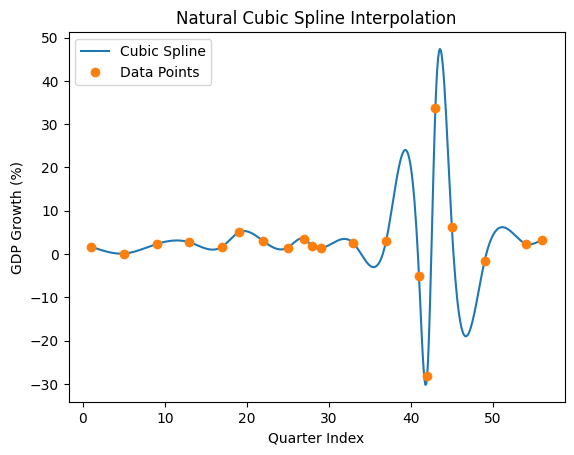

Number of quarterly evaluation points: 56


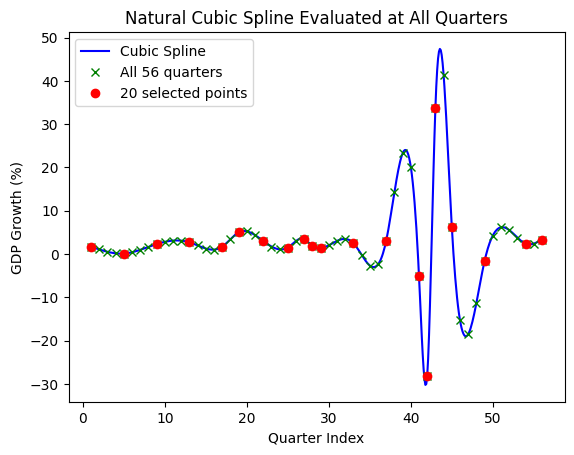


Degree-4 cond(X^T X): 159044757928.02097
Degree-4 RMSE: 10.0314
Cubic spline RMSE at knots: 0.0


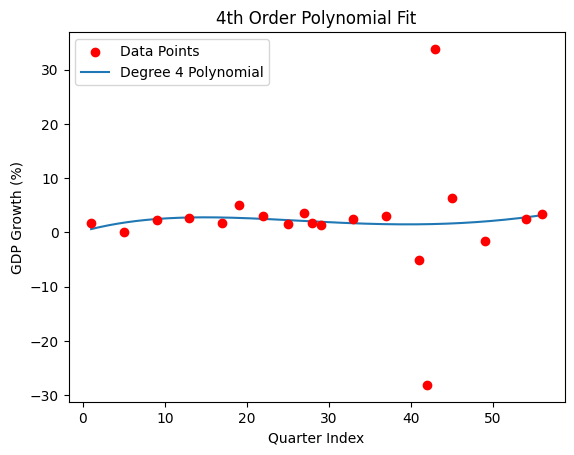

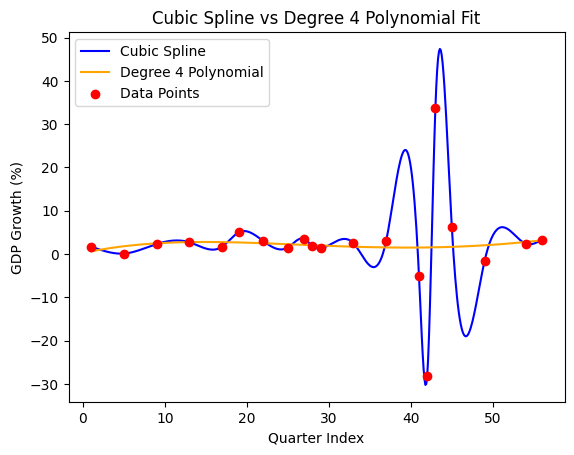

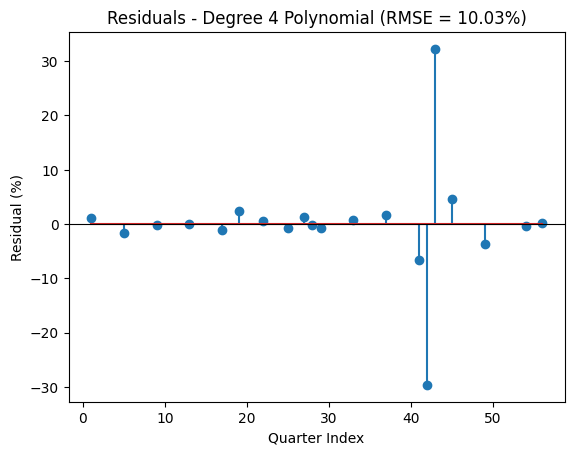


Linear fit slope (excl. COVID): -0.0019
Linear fit cond(X^T X): 3605.588551392816
Linear fit RMSE: 1.4432


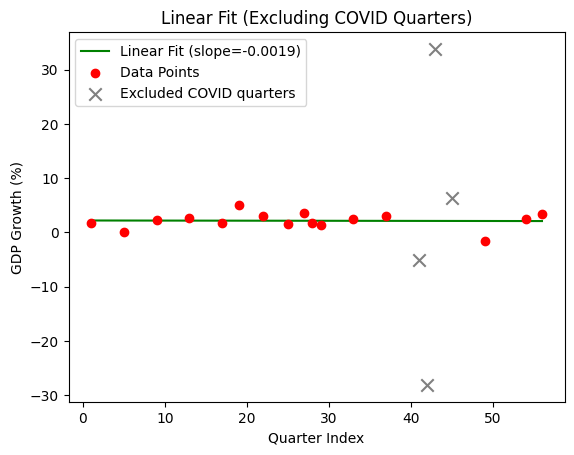

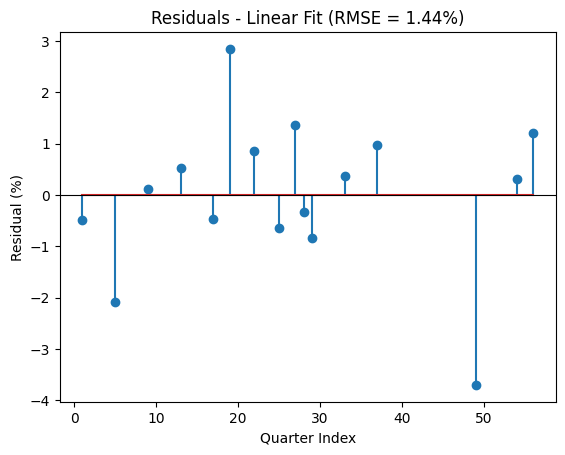

Summary: 

Spline RMSE at knots: 0.0
Degree-4 Poly RMSE: 10.0314
Linear Fit RMSE: 1.4432
Degree-4 cond(X^T X): 159044757928.02097
Linear cond(X^T X): 3605.588551392816
Linear slope: -0.0019


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Treating least squares as a special case of Polynomial Fit (polynomial of degree 1)
def polyFit(x_in, y, degree):
    if (degree < 0):
        return -1
    x = np.ones(y.size)
    if (degree < 1):
        return (x @ y) / x.size

    # Constructs the vandermonde matrix
    for i in range(1, degree + 1):
        x = np.column_stack((x, x_in ** i))

    return np.linalg.inv(x.T @ x) @ (x.T @ y)


def evaluateSpline(x, y, h, M, x_eval):
    y_out = np.zeros(len(x_eval))
    for k in range(len(x_eval)):
        for i in range(len(x) - 1):
            if x[i] <= x_eval[k] <= x[i + 1]:
                dx = x_eval[k] - x[i]
                a_i = y[i]
                b_i = (y[i + 1] - y[i]) / h[i] - h[i] * (2 * M[i] + M[i + 1]) / 6
                c_i = M[i] / 2
                d_i = (M[i + 1] - M[i]) / (6 * h[i])
                y_out[k] = a_i + b_i * dx + c_i * dx ** 2 + d_i * dx ** 3
                break
    return y_out


def computeRMSEValue(y_actual, y_predicted):
    return np.sqrt(np.mean((y_actual - y_predicted) ** 2))


# condition number of X^T X
def computeConditionNumber(x_in, degree):
    X = np.ones(len(x_in))
    for i in range(1, degree + 1):
        X = np.column_stack((X, x_in ** i))
    return np.linalg.cond(X.T @ X)


# ---- Dataset ----

gdp_growth = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
                        1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

# actual quarter indices on the timeline (2010 Q1 = 1, 2010 Q2 = 2, etc.)
x_data = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56])


# ---- Part A: Cubic Spline ----

x_spline = x_data.copy()
nSpline = len(x_spline)
h = np.diff(x_spline)

A = np.zeros(nSpline - 2)
B = np.zeros(nSpline - 2)
C = np.zeros(nSpline - 2)
D = np.zeros(nSpline - 2)

for i in range(1, nSpline - 1):
    A[i - 1] = h[i - 1]
    B[i - 1] = 2 * (h[i - 1] + h[i])
    C[i - 1] = h[i]
    D[i - 1] = 6 * ((gdp_growth[i + 1] - gdp_growth[i]) / h[i]
                     - (gdp_growth[i] - gdp_growth[i - 1]) / h[i - 1])

# Thomas algorithm forward sweep
b_length = len(B)
for i in range(1, b_length):
    w = A[i] / B[i - 1]
    B[i] = B[i] - w * C[i - 1]
    D[i] = D[i] - w * D[i - 1]

# back substitution
M_inner = np.zeros(b_length)
M_inner[-1] = D[-1] / B[-1]
for i in range(b_length - 2, -1, -1):
    M_inner[i] = (D[i] - C[i] * M_inner[i + 1]) / B[i]

# natural boundary conditions: M[0] = M[end] = 0
M = np.zeros(len(x_spline))
for i in range(len(M_inner)):
    M[i + 1] = M_inner[i]

x_spline_evaluation = np.linspace(x_spline[0], x_spline[-1], 500)
y_spline_evaluation = evaluateSpline(x_spline, gdp_growth, h, M, x_spline_evaluation)

# A1: cubic spline plot
plt.plot(x_spline_evaluation, y_spline_evaluation, label='Cubic Spline')
plt.plot(x_spline, gdp_growth, "o", label='Data Points')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth (%)')
plt.title('Natural Cubic Spline Interpolation')
plt.legend()
plt.show()

# A2: evaluate at every integer quarter in the spline domain
x_all_quarters = np.arange(int(x_spline[0]), int(x_spline[-1]) + 1, dtype=float)
y_all_quarters = evaluateSpline(x_spline, gdp_growth, h, M, x_all_quarters)
print("Number of quarterly evaluation points:", len(x_all_quarters))

plt.figure()
plt.plot(x_spline_evaluation, y_spline_evaluation, label='Cubic Spline', color='blue')
plt.plot(x_all_quarters, y_all_quarters, 'x', color='green', label='All ' + str(len(x_all_quarters)) + ' quarters')
plt.plot(x_spline, gdp_growth, 'o', color='red', label='20 selected points')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth (%)')
plt.title('Natural Cubic Spline Evaluated at All Quarters')
plt.legend()
plt.show()


# ---- Part B: Polynomial & Least Squares ----

x = x_data.copy()

# B1: degree 4 polynomial with centered basis
n = 4

# center x to improve condition number
x_mean = np.mean(x)
x_norm = x - x_mean

degreeNCoeffs = polyFit(x_norm, gdp_growth, n)

degreeNPoly = np.zeros(x.size)
for i in range(0, n+1):
    degreeNPoly = degreeNPoly + degreeNCoeffs[i]*x_norm**i

# smooth curve so the polynomial doesn't look jagged on the plot
x_smooth = np.linspace(x[0], x[-1], 500)
x_smooth_norm = x_smooth - x_mean

degreeNPoly_smooth = np.zeros(x_smooth.size)
for i in range(0, n+1):
    degreeNPoly_smooth = degreeNPoly_smooth + degreeNCoeffs[i]*x_smooth_norm**i

cond_deg4 = computeConditionNumber(x_norm, n)
rmse_deg4 = computeRMSEValue(gdp_growth, degreeNPoly)
print("\nDegree-4 cond(X^T X):", cond_deg4)
print("Degree-4 RMSE:", round(rmse_deg4, 4))

# spline RMSE at knots (should be ~0 since it interpolates exactly)
y_at_knots = evaluateSpline(x_spline, gdp_growth, h, M, x_spline)
rmse_spline = computeRMSEValue(gdp_growth, y_at_knots)
print("Cubic spline RMSE at knots:", round(rmse_spline, 6))

# poly fit plot
plt.figure()
plt.title('4th Order Polynomial Fit')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth (%)')
plt.scatter(x, gdp_growth, color='red', zorder=5, label='Data Points')
plt.plot(x_smooth, degreeNPoly_smooth, label='Degree 4 Polynomial')
plt.legend()
plt.show()

# comparison: spline vs degree 4
plt.figure()
plt.plot(x_spline_evaluation, y_spline_evaluation, label='Cubic Spline', color='blue')
plt.plot(x_smooth, degreeNPoly_smooth, label='Degree 4 Polynomial', color='orange')
plt.scatter(x, gdp_growth, color='red', zorder=5, label='Data Points')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth (%)')
plt.title('Cubic Spline vs Degree 4 Polynomial Fit')
plt.legend()
plt.show()

# residuals for degree 4 poly
residuals_deg4 = gdp_growth - degreeNPoly

plt.figure()
plt.stem(x, residuals_deg4)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xlabel('Quarter Index')
plt.ylabel('Residual (%)')
plt.title('Residuals - Degree 4 Polynomial (RMSE = ' + str(round(rmse_deg4, 2)) + '%)')
plt.show()


# B2: linear fit, excluding COVID quarters (2020 Q1 through 2021 Q1)
# COVID quarters are 2020 Q1 through 2021 Q1 -> indices 41, 42, 43, 45
covid_indices = [41, 42, 43, 45]
covid_mask = []
for i in range(len(x)):
    if x[i] not in covid_indices:
        covid_mask.append(True)
    else:
        covid_mask.append(False)
covid_mask = np.array(covid_mask)

x_no_covid = x[covid_mask]
y_no_covid = gdp_growth[covid_mask]

n1 = 1
degreeNCoeffs1 = polyFit(x_no_covid, y_no_covid, n1)

degreeNPoly1 = np.zeros(x_no_covid.size)
for i in range(0, n1+1):
    degreeNPoly1 = degreeNPoly1 + degreeNCoeffs1[i]*x_no_covid**i

x_line_smooth = np.linspace(x[0], x[-1], 500)
degreeNPoly1_smooth = np.zeros(x_line_smooth.size)
for i in range(0, n1+1):
    degreeNPoly1_smooth = degreeNPoly1_smooth + degreeNCoeffs1[i]*x_line_smooth**i

cond_deg1 = computeConditionNumber(x_no_covid, n1)
rmse_deg1 = computeRMSEValue(y_no_covid, degreeNPoly1)
slope = degreeNCoeffs1[1]

print("\nLinear fit slope (excl. COVID):", round(slope, 4))
print("Linear fit cond(X^T X):", cond_deg1)
print("Linear fit RMSE:", round(rmse_deg1, 4))

# linear fit plot - show excluded points in gray
plt.figure()
plt.plot(x_line_smooth, degreeNPoly1_smooth, label='Linear Fit (slope=' + str(round(slope, 4)) + ')', color='green')
plt.scatter(x_no_covid, y_no_covid, color='red', zorder=5, label='Data Points')
plt.scatter(x[~covid_mask], gdp_growth[~covid_mask], color='gray', zorder=5,
            marker='x', s=80, label='Excluded COVID quarters')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth (%)')
plt.title('Linear Fit (Excluding COVID Quarters)')
plt.legend()
plt.show()

# residuals for linear fit
residuals_deg1 = y_no_covid - degreeNPoly1

plt.figure()
plt.stem(x_no_covid, residuals_deg1)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xlabel('Quarter Index')
plt.ylabel('Residual (%)')
plt.title('Residuals - Linear Fit (RMSE = ' + str(round(rmse_deg1, 2)) + '%)')
plt.show()


# ---- Summary ----
print("Summary: \n")
print("Spline RMSE at knots:", round(rmse_spline, 6))
print("Degree-4 Poly RMSE:", round(rmse_deg4, 4))
print("Linear Fit RMSE:", round(rmse_deg1, 4))
print("Degree-4 cond(X^T X):", cond_deg4)
print("Linear cond(X^T X):", cond_deg1)
print("Linear slope:", round(slope, 4))



#AI Citations
# I used Claude Opus 4.6 to answer this prompt 
# "
# *INSERT ABOVE CODE HERE* (exluding the "x_mean = np.mean(x), x_norm = x - x_mean")
# My vandermonde matrix condition number seems sxceptionally high, I want you to think of ways I can fix this.
# "
# It recommended I do the apprach I implemented above, and also suggeested I divide by the std of x as well, however after trying just subtracting the mean the condition number was within the 10^12 bound.
# Looking back I understand why what I did worked because going from 1 to >50 when I'm raising them to the 4 will cause a massive range of values, so subtracting the mean puts them in a range roughly from -25 to 25 which cuts down a lot ~(1/2^4)

#(Normal) Sources Used:
# https://en.wikipedia.org/wiki/Tridiagonal_matrix_algorithm
# https://www.w3schools.com/python/matplotlib_intro.asp


# Introduction

This project analyzes U.S. quarterly GDP growth rates from 2010 to 2023 (Source: Bureau of Economic Analysis). The dataset represents the economic growth rate of 20 irregularly spaced quarters, including the extreme COVID-19 shock in 2020. This report will cover how cubic spline interpolation, 4th-degree polynomial least squares fitting, and linear least squares regression can be used to analyze this data. It will also compare their strengths and weaknesses in terms of data analysis, along with an analysis of how the algorithms behind each analysis will scale for large amounts of data.

## Part A

### Unknowns
There are 4 x n unknowns, where n is the number of intervals. Since we're interpolating between 20 points, we have 19 intervals, n = 19. Therefore, we would be solving for 4 x 19, 76 unknowns.

### Continuity Conditions
At each of the 18 interior knots, the spline must be:
1. The left and right splines about a knot must have the same value at the knot (Continuous - C0)
2. The first derivative of both left and right splines with respect to a knot must be equal at the knot (First Derivative Continuity - C1)
3. The second derivative of both left and right splines with respect to a knot must be equal at the knot (Second Derivative Continuity - C2)

### Boundary Conditions
For a Natural Spline, we set the second derivative to be equal to 0 at both endpoints of the spline (since we have a natural cubic spline, consider the endpoints to be inflection points of the cubic spline)

Note: Because the 20 data points are not evenly spaced in time (e.g., 2010 Q1 to 2011 Q1 is 4 quarters apart, but 2020 Q1 to 2020 Q2 is just 1), the interval widths h_i in the tridiagonal system are not all equal. This is why we use the actual quarter indices (1, 5, 9, ..., 54, 56) as our x-values rather than just 1 through 20 — the spacing matters for getting the spline shape right.

### Smoothness of Interpolant
I think the interpolant is definitely smooth and connected. It doesn't feel jerky at any point, and the actual crossover between intervals is indistinguishable from the global spline. This is due to the C1 and C2 restriction we place at every point. Forcing the function to look cohesive as a whole.

I do, however, think that the logic of the spline breaks down near the COVID quarters (indices 41–45), as we're forcing the spline to go through what we know now to be outliers. I think this data could benefit from a least squares analysis to show how significantly strange this period of time was, and to treat those data points with less trust when forming an interpolation.

### Runge Phenomenon Analysis
When we have to interpolate between a value like -28 and the very next point in the interval, which must increase to 33, we can observe some unusual behavior in the spline, as it has to create a contour to make that sharp change. However, other than that in general it has pretty smooth behavior in general, especially near endpoints. This is due to their piece wise nature, effectively allowing us to have a lot of inflection points while each intervals' polynomial is only order 3. This effectively mitigates Runge's Phenomenon.

This is in contrast to least squares, where as you increase the order of the spline interpolation polynomial, due to Runge's Phenomenon, there will be oscillations both during the selected interval, and at the endpoints onward, we will see sharp odd/even function behavior. (left and right sides of the interval will either move together (even) or inversely (odd)).

In other words, in exchange for exact interpolation, we are accepting a decrease in numerical stability (the assumption being our data is so clean that we don't need to have much stability in our processing of it, since the data itself is assumed to be perfectly stable inherently)

This is, again, in contrast to Least Squares, where you forgo exact interpolation in exchange for numerical stability (for sufficiently low orders of polynomials)

In my opinion, I would trust least squares analysis for economic data, due to the inherent noise of measurements. Economic data, as you can imagine, is incredibly hard to measure, and usually, most data collection metrics are assembled from surveys, old tax records, etc. Furthermore, it's quite common for these metrics to become revised (potentially with significant changes in the revision). Due to the inherently noisy nature of these readings and the major outliers caused by the COVID-19 Pandemic, I would trust the least squares interpolation more.

---

## Part B

### Least Squares vs. Cubic Spline
The least squares interpolation better captures the overall trend, ignoring outliers. The cubic spline interpolation best reproduces specific data points. Quantitatively, the cubic spline has an RMSE of 0 at the knots (by construction, since it passes through every point), while the degree-4 polynomial has an RMSE of about 10.03%. That RMSE is high, but it's almost entirely driven by the COVID outliers — the polynomial is deliberately smoothing over them rather than chasing them.

### Tradeoff between Approximation and Interpolation
Approximation is good when you don't fully trust your data points but do believe that they are generally representative of some quantity. So, you will consider what all of them tell you to make one best guess fit for your data, but you won't force your approximation to exactly equal any one data point. Generally, this is because you hope that the noise that is causing your data to be unreliable will destructively interfere with all your samples so that your final trend will be clean.

In contrast, exact interpolation should be used when you fully trust your given data sets. Exact-interpolation will mean that the interpolation will pass through your reference points, unlike least squares regression. So, when you know you have negligible noise in your data (have really good sensors, or measurements are over a really short time span, so noise doesn't have a chance to build up, etc.), it is beneficial to do an exact interpolation.

In short, if you really, really, really trust your data readings, then do exact-interpolation, else you should do a least squares regression.

### Does a linear trend make sense?
The linear fit was performed excluding the COVID quarters (2020 Q1 through 2021 Q1), since those extreme values would dominate the fit and obscure the underlying trend. With those removed, the slope of the best-fit line is approximately -0.0019, which is essentially zero. The RMSE for this fit is about 1.44%. This makes sense, since GDP growth fluctuates around a roughly constant average, and the linear model captures that average.

A linear trend would imply that the economy is accelerating/decelerating at a constant rate through time.
(Slope of best fit line is change in growth rate over change in time, which is just the second derivative of economic growth over time)
This is objectively not true. The economy operates in cycles where, at certain times, we are booming and others where we're in a bust period. Since the slope of the best-fit line is close to zero, it would be reasonable to assume the growth rate had stayed stagnant through this period, but that is measurably incorrect. All a linear trend shows you is what the data tends to do on average.

### Assumptions of a linear trend


1. Constant Rate of Change of the Economic Growth Rate over time
2. No cyclical behavior in the Economy
3. Errors/Noise is destructive, meaning on average, over a lot of samples, we tend to have an equal distribution of events that are above average as well as below average.
(Roughly equal amounts of "positive"/"negative" noise)

To avoid poor numerical conditioning, I centered the x values by subtracting them from the mean before constructing the Vandermonde matrix. I've recorded the condition number of X^T X for the degree-4 polynomial to be approx. 1.59 x 10^11, which is below the 10^12 threshold. The linear fit's condition number is about 3,606, also well-behaved. Before doing this, the raw x-values (1 to 56) raised to the 4th power produced a condition number on the order of 10^14, so this was necessary to be under the 10^12 threshold.

---

## Part C

I would recommend that the policymaker use the Cubic Spline for this economic data, for three reasons.

1. Smoothness: Both least-squares and cubic splines produce smooth curves. However, the cubic spline is unreliable near outliers. During the COVID-19 Pandemic, the spline had to make extreme swings to pass through 28.1% and 33.8% back to back. Producing values between those knots is arguably meaningless, since the cubic spline significantly overcorrects so that it can go through them. On the contrary, the polynomial stays calm throughout because it's not forced to hit any single point. However if the objective is to have an acuurate interpolatio nbetween 2 known data points, I think the edge is still with the cubic split interpolation, because it will output more "representative" values within the subinterval.

2. Accuracy: I think it matters how we define accuracy. The spline is perfectly accurate at the 20 known data points, since it hits every one exactly (RMSE = 0 at knots). However, a policymaker would care more about accuracy between the known points (that's the entire point of interpolation after all). The degree-4 polynomial has an RMSE of 10.03%, but that number is inflated by the COVID outliers. At normal quarters, the polynomial tracks the data reasonably well. Near the COVID shock, the polynomial's estimate of "what GDP growth was doing in a typical quarter" is more useful for policy decisions than the spline's wild oscillation between -28 and +34. However if we only care about any 2 data points, I think the cubic spline takes the edge strictly due to the fact that the degree-4 polynomial is more-so representative of the trend of the data, so for long-term decision making I would trust the least squares polynomial more, however for shorter intervals I would prefer the cubic spline. 

3. Sensitivity to Outliers: Least Squares Regression is vastly more resilient towards outliers in the data, and it doesn't place complete trust in any one, two, or three data points. Instead, it considers all the points when creating a global polynomial fit. This is in contrast to the cubic spline, which only cares about the 2 points between each interval (and considers the previous spline as well), which therefore makes it extremely sensitive to outliers. This sensitivity to outliers can be thought of as numerical instability, where if the input data has even a little bit of noise, the cubic spline vastly overcorrects and creates very unstable polynomials. Because economic data is noisy due to the reasons discussed earlier, as well as the COVID-19 Pandemic, using the least squares polynomial fit is generally more robust.

Something important to note is that splines are designed to make sure the interpolation will go through given data points. Least squares interpolations do not offer that guarantee. I'm recommending Cubic Splines for this particular example, due to the fact that the interval provided isn't particularly long term, and the data points the policymaker will pick are likely to shrink that interval even further. Therefore, the cubic spline will be more representative of the data. There are, of course, other methods such as smoothing splines which may be suitable for this data (assuming conditioning out the COVID-19 affected data). However strictly based on the interpolations this project covers, the Cubic Spline is the best choice for this data.

---

## Part C - Addendum

### Big O Notation for All Given Algorithms

---

#### 1. Cubic Spline: O(n)

There are three relevant stages to consider when looking at the time complexity of generating a cubic spline. Consider "n" to be the number of points to generate a spline for.

Stage 1: Setup — O(n)
- Need to compute the interval widths, which is n - 1 subtractions. This scales to O(n) (we can drop the -1 since it doesn't contribute for large n).
- Need to assign the left endpoint value to be the "a" coefficient for each interval (a_i = y_i). That's n - 1 assignments = O(n).
- Need to fill in the four arrays A, B, C, and D that represent the tridiagonal system. There are n - 2 interior knots, and each one requires a constant number of arithmetic operations (c) to compute its row. So that's O(c x (n - 2)), but again, for large enough n, we can approximate to O(n).

Stage 2: Solving the Tridiagonal System (Thomas Algorithm) — O(n)
- Forward sweep: We loop from row 1 to the last row, and at each row we do exactly 5 operations (one division to get the ratio, two multiply and two subtracts to update B and D). The loop runs n - 3 times, so that's 5(n - 3) operations, which again becomes O(n) for sufficiently large n. Something important to note is that the reason this feels so cheap is that the tridiagonal matrix is inherently quite sparse (mostly 0). The Thomas algorithm exploits this by only considering the diagonal rows and storing them directly as vectors (instead of performing Gaussian elimination on the entire matrix).
- Back substitution: We start from the last row (which now has one unknown, so we solve it with one division) and work backwards. Each step is 3 operations (multiply, subtract, and divide). The loop runs n - 3 times, so that's 3(n - 3) + 1 operations. This scales to O(n) for sufficiently large n.

Stage 3: Computing the Remaining Coefficients — O(n)
- Once we have all the M values (second derivatives), computing d_i and b_i for each interval is just plugging into a formula. Each formula is a fixed number of arithmetic operations. We do this n-1 times (once per interval). This also scales to O(n) for sufficiently large n.

Total: O(n) + O(n) + O(n) = O(n) (for sufficiently large n).

---

#### 2. Degree-k Polynomial Fit (Least Squares): O(nk^2)

Consider "n" to be the number of data points and "k" to be the degree of the polynomial (in our case, k = 4, so we're fitting 5 coefficients). The code computes coefficients as `inv(X_T x X) x (X_T x y)`.

1. Building the Vandermonde matrix X — O(nk): The matrix is n rows by (k+1) columns. Each cell is one computation (raise x_i to a power). Total: n x (k+1) cells. This converges to O(nk) for large n and k.

2. Computing X_T x X — O(nk^2): The result is a (k+1) x (k+1) matrix, which for k = 4 is just 5 x 5 = 25 entries. But each entry requires a dot product of two columns of X, and each column has n entries. So (k+1)^2 x n. But for sufficiently large n and k, this scales to O(nk^2).

3. Inverting X_T x X — O(k^3): We're inverting a (k+1) x (k+1) matrix. From a quick Google search, we can see that the inverse operation has a complexity of O(n^3) where n is the number of elements along a row/column of a square matrix. So in our case, we would have O((k+1)^3). However, again, for sufficiently large k, we have O(k^3).

4. The remaining multiplies — O(nk): Computing X_T x y means multiplying a (k+1) x n matrix by an n x 1 vector, which produces a (k+1) x 1 vector. Each of those k+1 entries is a dot product of length n, so that's (k+1) x n operations. This will again converge to O(nk) for large k and n. The final step multiplies the (k+1) x (k+1) inverse by that (k+1) x 1 vector, which is (k+1)^2 operations, which scales to O(k^2) for large enough k. This might cause you to ask why the answer isn't O(nk + k^2), and the reason is that it is implied that n is significantly larger than k, because we don't want to have a best-fit polynomial of a higher order than the number of data points we have. This would cause severe Runge's Phenomenon and is never advisable. Based on this assumption, we can simplify the notation to be O(nk).

Total: O(nk^2) dominated by the X_T x X computation (we ignore k^3, because again, k is presumed to be significantly lower than n). Since k = 4 is fixed in our problem, k^2 = 16 is just a constant, so the effective time complexity is O(16 x n), which scales to O(n) for sufficiently large n. But if we increased the polynomial degree, the cost would grow quadratically with k.

Side Note:
When I say O(16 x n) scales to O(n), for example, the behavior of O(16 x n) is roughly similar to O(n).
Ex. 16 x 1,000,000,000 is on the same order as just 1,000,000,000 (still in the billions).

---

#### 3. Linear Fit (k = 1): O(n)

This is just the polynomial fit with k = 1. Plugging k = 1 into every step above:

1. Building X: n x 2 matrix = O(n)
2. Computing X_T x X: 2 x 2 = 4 entries, each a dot product of length n = O(n)
3. Inverting X_T x X: inverting a 2 x 2 matrix is a constant-time formula = O(1)
4. Remaining multiplies: O(n)

Total: O(n). With k = 1, everything that depended on k collapsed to a constant. The only work that scales with n is summing over the data points.

---

#### Does Big O Change My Recommendation?

No, it doesn't. All three algorithms are effectively O(n) for our problem since k is fixed and small. The cubic spline is O(n), the polynomial fit is O(nk^2) but with k = 4 that's just O(16n) which is still O(n), and the linear fit is O(n). So none of them have a computational advantage over the others at this scale. The recommendation mainly comes down to accuracy, not scalability (since all three algorithms have effectively linear time complexity).

---

## Conclusion

Overall, least squares interpolation between known data points is ideal when your data is affected by noise. However, if you are extremely confident in your data and would benefit from an interpolation that passes through your known data points, then the cubic spline becomes much more compelling. Given the instability caused by the COVID-19 Pandemic in this dataset, the 4th order least squares approximation is the most effective tool for interpolation. For trend analysis, the linear fit (excluding COVID) confirms that GDP growth stayed roughly flat on average over this period, with a near-zero slope. If accurate interpolation at any given input is vital, then spline interpolation becomes appealing. However, for understanding the general trend of your data, least squares analysis is more fruitful.
